In [33]:
import os
import numpy as np
import pandas as pd
import nibabel as nib

import matplotlib.pyplot as plt

from nilearn.image import concat_imgs, resample_to_img
from nilearn.masking import apply_mask
from nilearn.datasets import fetch_atlas_pauli_2017
from nilearn.plotting import view_img, plot_img

# =========================
# --- Helper Functions ----
# =========================

def cut_mask():

    # path to your mask (in_file is currently hardcoded, but keeping for context)
    in_file = "/mnt/projects/rewardMap/STUDIES/pilotstudy/derivatives/masks/tpl-MNI152NLin2009cAsym_res-02_desc-brain_mask.nii.gz"
    # out_file is defined but not used in the plotting part, so we omit it here

    # load image
    nii = nib.load(in_file)
    data = nii.get_fdata()
    affine = nii.affine
    header = nii.header
    print(data.shape)
    n_slices = 12
    # remove the lowest 4 slices along the Z-direction
    trimmed = data[:, :, n_slices:]    # drop slices 0–3
    trimmed = np.concatenate((np.zeros_like(data[:, :, :n_slices]), trimmed), axis=2)  # just to show original vs trimmed
    print(trimmed.shape)
    # Create the Nifti image object for the trimmed data
    trimmed_nii = nib.Nifti1Image(trimmed, affine, header)

    # Visualize the trimmed mask - this must be the LAST line of the cell!
    return plot_img(trimmed_nii, bg_img=None, cut_coords=(0, -46, 0), draw_cross=False, display_mode='ortho')

# Example call in a separate cell:

(97, 115, 97)
(97, 115, 97)


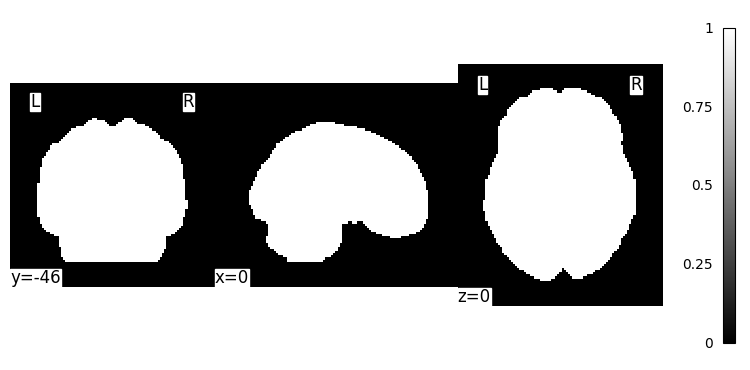

In [34]:
cut_mask()